In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import astropy.constants as const

In [ ]:
def freq(tau, m1, m2):
    M_c = np.power(m1*m2, 3/5)/np.power(m1+m2, 1/5)
    f = 1/np.pi*np.power(5/256* 1/tau, 3/8)*np.power(const.G.value*M_c/const.c.value**3, -5/8)
    return f

def strain(t, m1, m2, r, theta, phi):
    t_ret = t 
    tau = - t
    M_c = np.power(m1*m2, 3/5)/np.power(m1+m2, 1/5)
    f = freq(tau, m1, m2)
    prefactor = 4/r*np.power(const.G.value*M_c/const.c.value**2, 5/3)*np.power(np.pi*f/const.c.value, 2/3)
    h_plus = prefactor*(1+np.cos(theta)**2)/2*np.cos(2*np.pi*f*t_ret + 2*phi)
    h_cross = prefactor*np.cos(theta)*np.sin(2*np.pi*f*t_ret + 2*phi)
    return h_plus, h_cross

In [73]:
T = 0.5
df = 2048
t = np.linspace(-T, 0, int(df*T))
r = 500E+3*const.kpc.value
m1 = 30*const.M_sun.value
m2 = 40*const.M_sun.value
h = strain(t, m1=m1, m2=m2, r=r, theta=np.pi, phi=0)

def radius(t, m1, m2):
    tau = -t
    f = freq(tau, m1, m2)
    r = np.power(const.G.value*(m1+m2)/(np.pi*f)**2, 1/3)
    return r

t_motion = -np.logspace(-20, np.log10(T), 8000)
tau = -t_motion
f = freq(tau, m1, m2)
a = radius(-T, m1, m2)*np.power(t_motion/(-T), 0.25)
x = a*np.cos(np.pi*f*t_motion)
y = a*np.sin(np.pi*f*t_motion)

/tmp/ipykernel_1083229/2205524439.py:3: RuntimeWarning: divide by zero encountered in divide
  f = 1/np.pi*np.power(5/256*1/tau, 3/8)*np.power(const.G.value*M_c/const.c.value**3, -5/8)
/tmp/ipykernel_1083229/2205524439.py:12: RuntimeWarning: invalid value encountered in multiply
  h_plus = prefactor*(1+np.cos(theta)**2)/2*np.cos(2*np.pi*f*t_ret + 2*phi)
/tmp/ipykernel_1083229/2205524439.py:13: RuntimeWarning: invalid value encountered in multiply
  h_cross = prefactor*np.cos(theta)*np.sin(2*np.pi*f*t_ret + 2*phi)


In [74]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

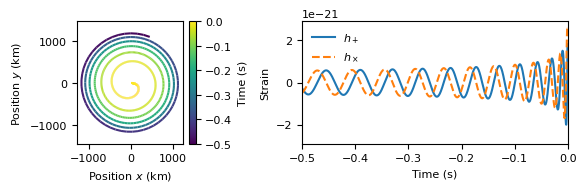

In [75]:
def gradient(ax, x, y, z, cmap="viridis",**kwargs):
    xy = np.array([x, y]).T                
    segments = np.stack([xy[:-1], xy[1:]], axis=1) 
    lc = matplotlib.collections.LineCollection(segments=segments, array=z, cmap=cmap, **kwargs)
    ax.add_collection(lc)
    ax.autoscale()
    return lc

fig, (ax1, ax2) = plt.subplots(ncols=2, width_ratios=[1, 2], figsize=(15/2.54, 5/2.54))
ax1.axis("equal")
cmap = "viridis"
delta = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
dist = np.insert(np.cumsum(delta), 0, 0)
interp = np.interp(dist[:-1] + np.diff(dist)/2, dist, t_motion)
lc = gradient(ax1, x[:-1]/1E+3, y[:-1]/1E+3, z=interp[:-1], cmap=cmap, clim=(-T, 0))
cbar = fig.colorbar(lc, ax=ax1, orientation="vertical")
cbar.set_label("Time (s)")
ax1.set_xlabel(r"Position $x$ (km)")
ax1.set_ylabel(r"Position $y$ (km)")
ax2.plot(t, h[0], label=r"$h_+$")
ax2.plot(t, h[1], ls="--", label=r"$h_\times$")
ylim = ax2.get_ylim()
ax2.set_ylim(-np.max(np.abs(ylim)), np.max(np.abs(ylim)))
ax2.set_xlim(-T, 0)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Strain")
ax2.legend(frameon=False)
fig.tight_layout()
fig.savefig("waveform.png", dpi=300, bbox_inches="tight")